# Session 1: Exploring Sklearn Classification Models

## Learning Objectives

In this session, we will:

1. **Explore decision trees** for intuitive, rule-based classification
2. **Compare ensemble methods** (Random Forest, Gradient Boosting / AdaBoost) to a single tree
3. **Experiment with a simple neural network** using the sklearn API
4. **Visualize decision boundaries and model behavior** in 2D feature space
5. **Tune key hyperparameters** and observe their impact
6. **Use cross-validation and grid search** (`GridSearchCV`) with a focus on **F1-score**

The goal is to understand **how models behave**, not to build the best possible classifier on a particular dataset. We will use simple synthetic datasets from `sklearn.datasets` so that the **decision boundaries** are easy to visualize.


## 1. Setup and Dataset

We will start from a **simple, low-dimensional dataset** so that we can easily visualize decision boundaries.

We will use two types of datasets from `sklearn.datasets`:

- `make_moons`: Non-linear binary classification with two interleaving half circles
- `make_classification`: Configurable synthetic dataset, where we can control class overlap and class balance

We will:
- Generate a 2D dataset
- Split into train and test sets
- Visualize the raw data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

In [2]:
# Configuration: choose dataset and difficulty

DATASET_NAME = "moons"  # options: "moons", "classification_easy", "classification_hard"
N_SAMPLES = 1000
TEST_SIZE = 0.3
NOISE = 0.25  # used for moons
CLASS_SEP = 0.1  # used for make_classification
FLIP_Y = 0.0     # label noise for make_classification

print(f"Using dataset: {DATASET_NAME}")


def make_dataset(dataset_name: str, random_state: int = RANDOM_STATE):
    """Return X, y according to the configuration above.

    This lets you quickly switch datasets in class to show when
    more complex models start to outperform simpler ones.
    """
    if dataset_name == "moons":
        X, y = make_moons(
            n_samples=N_SAMPLES,
            noise=NOISE,
            random_state=random_state,
        )
    elif dataset_name == "classification_easy":
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_clusters_per_class=1,
            class_sep=CLASS_SEP,  # large separation = easier
            flip_y=FLIP_Y,
            random_state=random_state,
        )
    elif dataset_name == "classification_hard":
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_clusters_per_class=2,
            class_sep=CLASS_SEP,  # smaller separation = harder
            flip_y=FLIP_Y,
            random_state=random_state,
        )
    else:
        raise ValueError(f"Unknown dataset_name: {dataset_name}")

    return X, y


# Generate dataset according to configuration
X, y = make_dataset(DATASET_NAME, random_state=RANDOM_STATE)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (test):", np.bincount(y_test))

Using dataset: moons
X_train shape: (700, 2)
X_test shape: (300, 2)
Class distribution (train): [350 350]
Class distribution (test): [150 150]


## TODO - visualize `X_train` data as a scatter plot

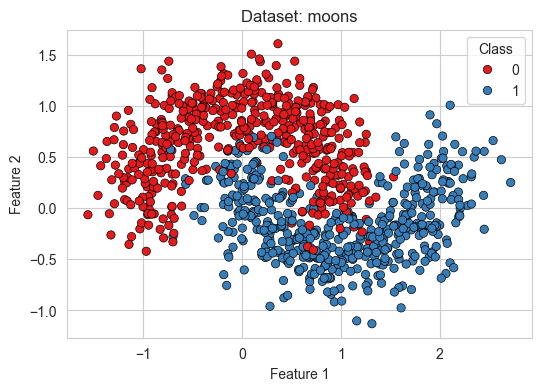

In [7]:
# Visualize the raw data

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k")
plt.title(f"Dataset: {DATASET_NAME}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.show()

### Question 1.1: Dataset Intuition

Look at the scatter plot of the training data.

- **Where is the non-linearity in this problem?**
- **Would a linear classifier (e.g. logistic regression) perform well here? Why or why not?**

**Answer (example):**
- ...


## 2. Decision Trees: Intuition, Visualization, and Hyperparameters

Decision trees are **rule-based models** that recursively split the feature space.

They are particularly useful for teaching because:
- They are **interpretable** (we can visualize the tree structure)
- They naturally create **piecewise-constant decision regions** in 2D
- Their behavior changes clearly with a few key hyperparameters:
  - `max_depth`
  - `min_samples_split`
  - `min_samples_leaf`


# TODO - 

- make a function (see sklearn's API) that plots the decision boundary in 2D
- Train a decision tree on X and y and print its metrics
- plot the decision tree's boundary and it's decision "graph" (see `plot_tree`)

In [17]:
def plot_decision_boundary(model, X, y, **kwargs):
    """Utility function to plot the decision boundary of a fitted classifier in 2D."""

    model.fit(X, y)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, **kwargs)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", alpha=0.8)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(title="Class")
    plt.title(f"Decision Boundary: {model.__class__.__name__}")
    plt.show()

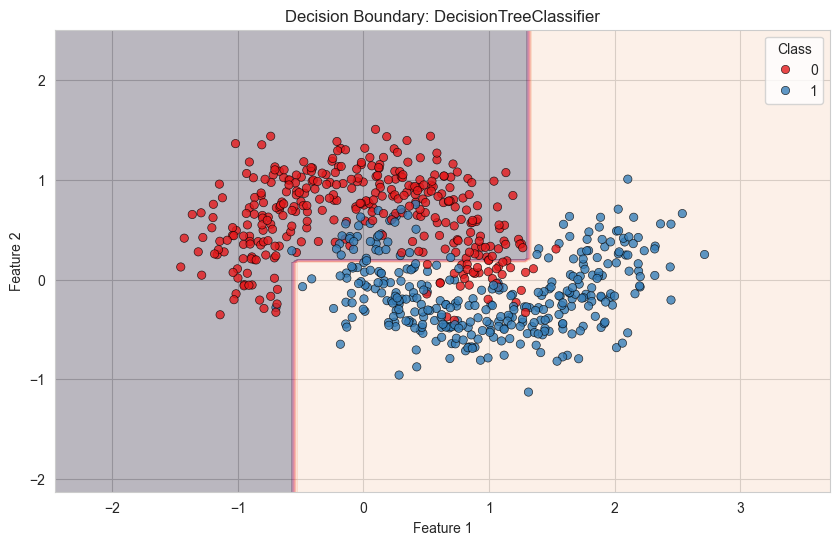

Decision Tree (max_depth=3)
  Train accuracy: 0.899
  Test accuracy:  0.927
  Train F1:       0.898
  Test F1:        0.924


In [18]:
# Train a simple decision tree

simple_tree = DecisionTreeClassifier(
    max_depth=3, random_state=RANDOM_STATE,
    
)
simple_tree.fit(X_train, y_train)

plot_decision_boundary(simple_tree, X_train, y_train)

# Evaluate
y_train_pred = simple_tree.predict(X_train)
y_test_pred = simple_tree.predict(X_test)

print("Decision Tree (max_depth=3)")
print(f"  Train accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"  Test accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")
print(f"  Train F1:       {f1_score(y_train, y_train_pred):.3f}")
print(f"  Test F1:        {f1_score(y_test, y_test_pred):.3f}")

In [ ]:
# Visualize decision boundary for the simple tree

raise NotImplementedError("Fill out the TODO")

...

### Question 2.1: Interpreting the Tree

Look at the **tree plot** and the **decision boundary**.

- **What kind of splits does the tree make?** (vertical / horizontal? which feature?)
- **How does increasing `max_depth` change the shape of the decision regions?**

**Answer (example):**
- ...


# TODO play with `max_depth` and see the impact on the decision boundary - use very low and very high values

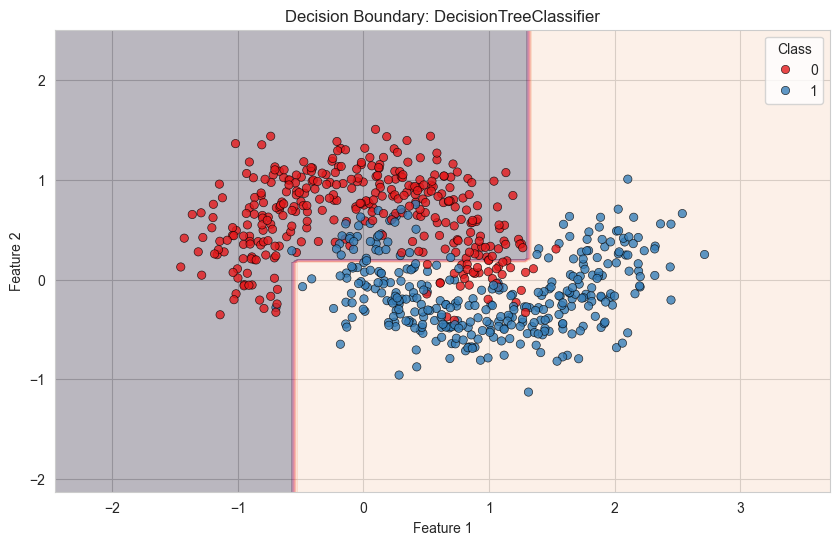

Decision Tree (max_depth=3)
  Train accuracy: 0.899
  Test accuracy:  0.927
  Train F1:       0.898
  Test F1:        0.924


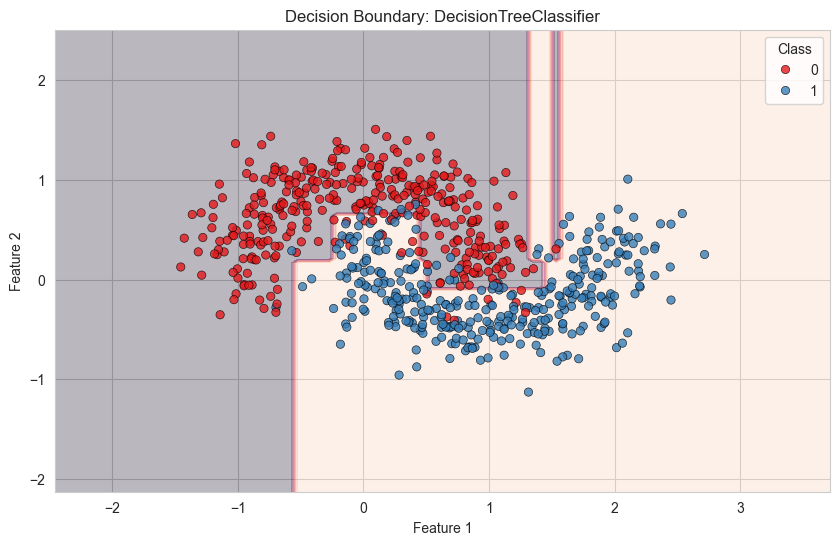

Decision Tree (max_depth=3)
  Train accuracy: 0.963
  Test accuracy:  0.950
  Train F1:       0.963
  Test F1:        0.950


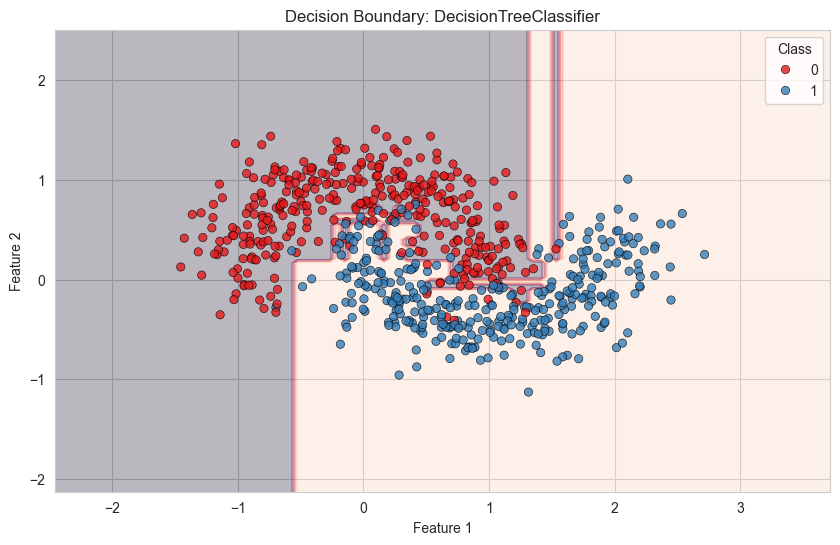

Decision Tree (max_depth=3)
  Train accuracy: 1.000
  Test accuracy:  0.953
  Train F1:       1.000
  Test F1:        0.952


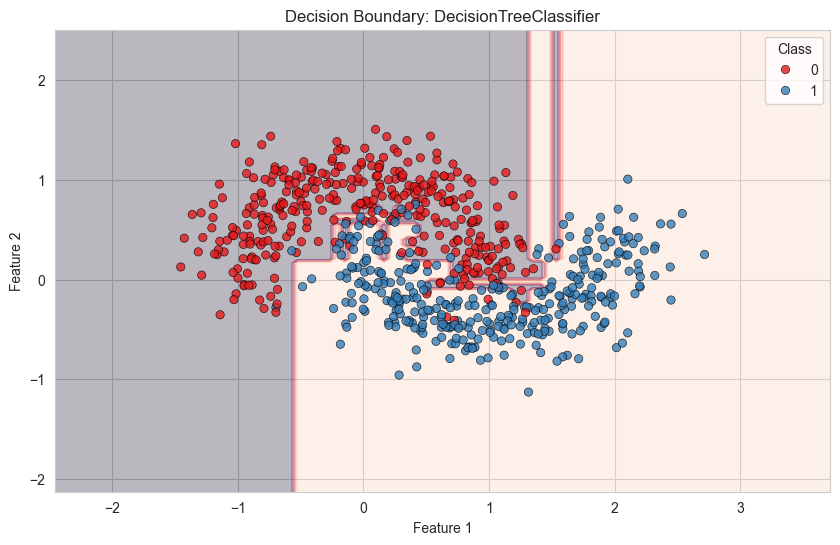

Decision Tree (max_depth=3)
  Train accuracy: 1.000
  Test accuracy:  0.953
  Train F1:       1.000
  Test F1:        0.952


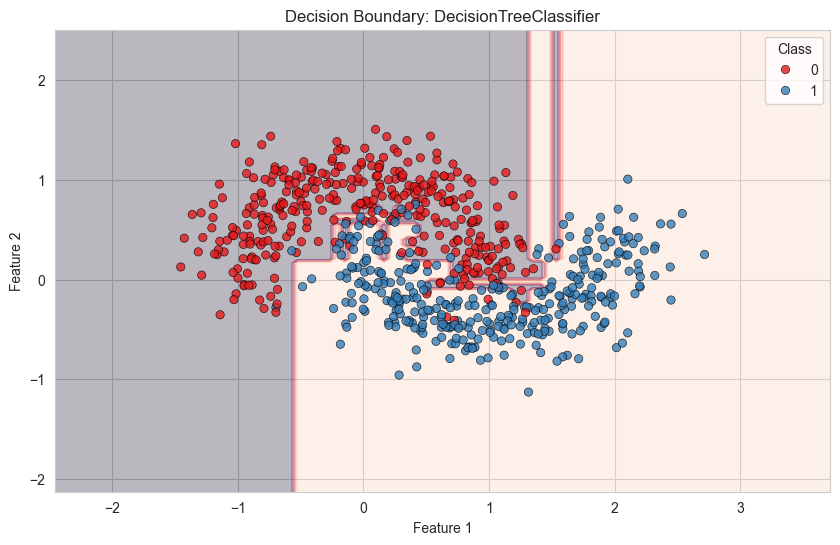

Decision Tree (max_depth=3)
  Train accuracy: 1.000
  Test accuracy:  0.953
  Train F1:       1.000
  Test F1:        0.952


In [20]:
# Explore the effect of max_depth on decision boundaries

max_depth_values = [3,5,50,100, 200]

for i, depth in enumerate(max_depth_values):

    simple_tree = DecisionTreeClassifier(
        max_depth=depth, random_state=RANDOM_STATE,
        
    )
    simple_tree.fit(X_train, y_train)

    plot_decision_boundary(simple_tree, X_train, y_train)

    # Evaluate
    y_train_pred = simple_tree.predict(X_train)
    y_test_pred = simple_tree.predict(X_test)

    print("Decision Tree (max_depth=3)")
    print(f"  Train accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
    print(f"  Test accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")
    print(f"  Train F1:       {f1_score(y_train, y_train_pred):.3f}")
    print(f"  Test F1:        {f1_score(y_test, y_test_pred):.3f}")

### Question 2.2: Underfitting vs Overfitting

Compare the decision boundaries for different `max_depth` values.

- For which `max_depth` values does the model **underfit**? Why?
- For which `max_depth` values does the model start to **overfit**? What visual clues do you see?

**Answer (example):**
- ...


## 3. Ensembles: Random Forest and Boosting

Single trees are **high-variance** models: they can change a lot if the training data changes slightly.

Ensembles combine many trees to get **more stable and often more accurate** models:

- **Random Forest**: many deep trees, trained on bootstrapped samples with random feature subsets (bagging)
- **Boosting (e.g. AdaBoost, GradientBoosting)**: trees are added sequentially to correct previous errors

We will compare:
- A single decision tree
- A random forest
- A gradient boosting classifier (similar spirit to AdaBoost)

We will use the same dataset and visualize their decision boundaries and performance.


# TODO - fit a DecisionTree, a RandomForestClassifier and a GradientBoostingClassifier on the same data, and print the metrics + boundaries

In [21]:
# Define models

base_tree = DecisionTreeClassifier(
    max_depth=5, random_state=RANDOM_STATE,
)
random_forest = RandomForestClassifier(
    max_depth=5, n_estimators=100, random_state=RANDOM_STATE,
)
grad_boost = GradientBoostingClassifier(
    max_depth=5, n_estimators=100, random_state=RANDOM_STATE,
)

models = {
    "Decision Tree (depth=5)": base_tree,
    "Random Forest (100 trees)": random_forest,
    "Gradient Boosting": grad_boost,
}

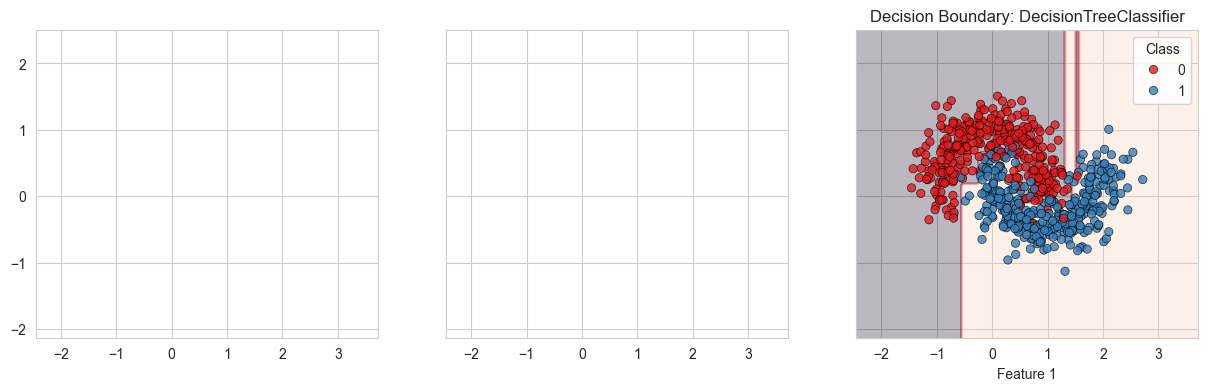

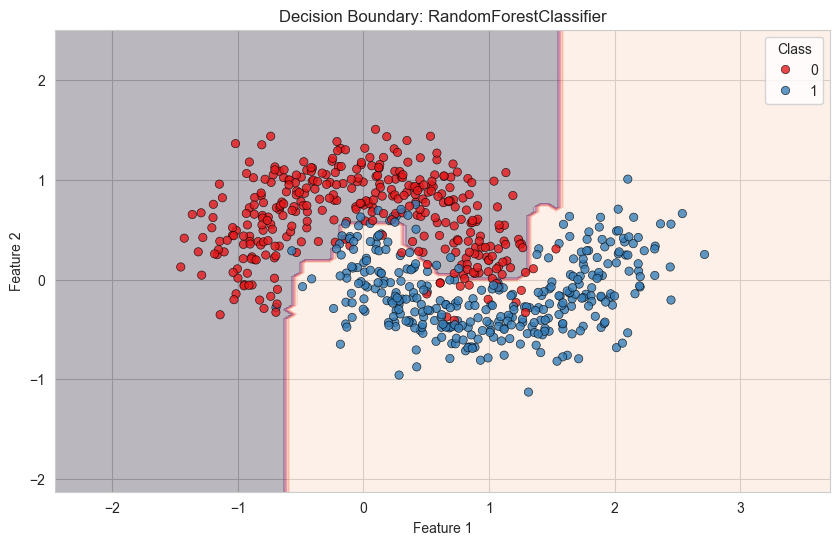

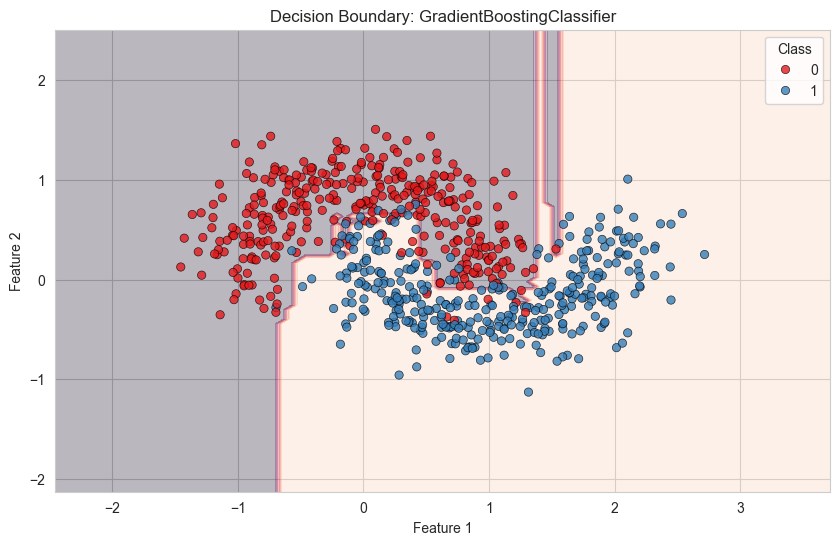

<Figure size 1000x600 with 0 Axes>

In [25]:
# Visualize decision boundaries for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    plot_decision_boundary(model, X_train, y_train)

plt.tight_layout()
plt.show()

### Question 3.1: Why Ensembles?

Compare the **F1-scores** and **decision boundaries** of the three models.

- How does the random forest boundary differ from the single tree?
- How does gradient boosting behave compared to random forest?
- Which model seems to **overfit** or **underfit** in this setting?

**Answer (example):**
- ...


# TODO - play with the below hyperparams and visualize the impact on a RandomForestClassifier's boundary

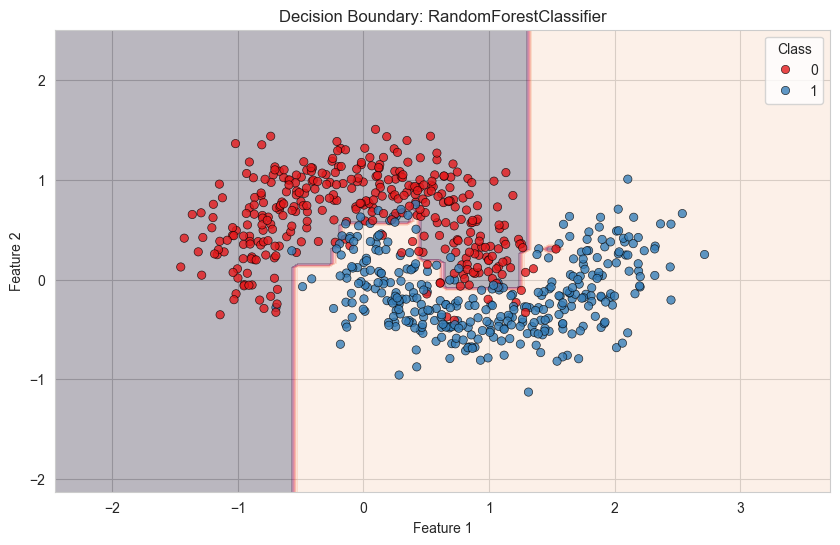

Decision Tree (max_depth=3)
  Train accuracy: 0.953
  Test accuracy:  0.973
  Train F1:       0.953
  Test F1:        0.973


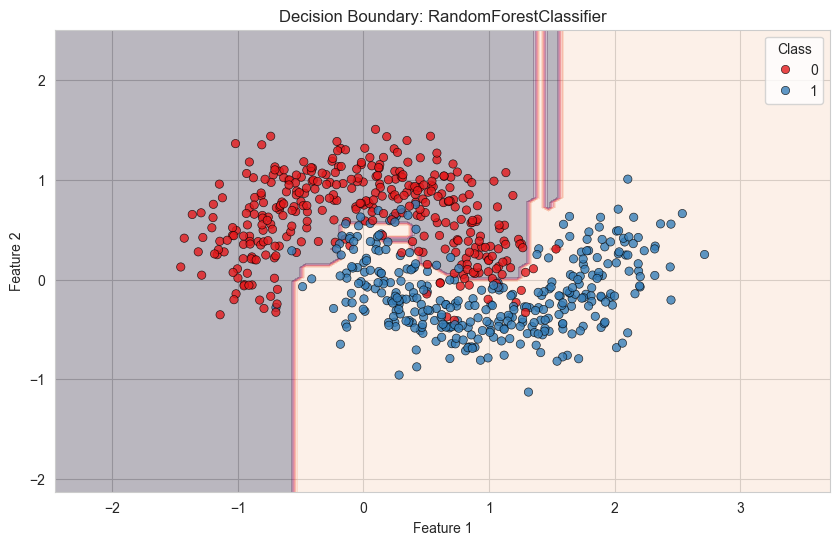

Decision Tree (max_depth=3)
  Train accuracy: 0.951
  Test accuracy:  0.973
  Train F1:       0.952
  Test F1:        0.973


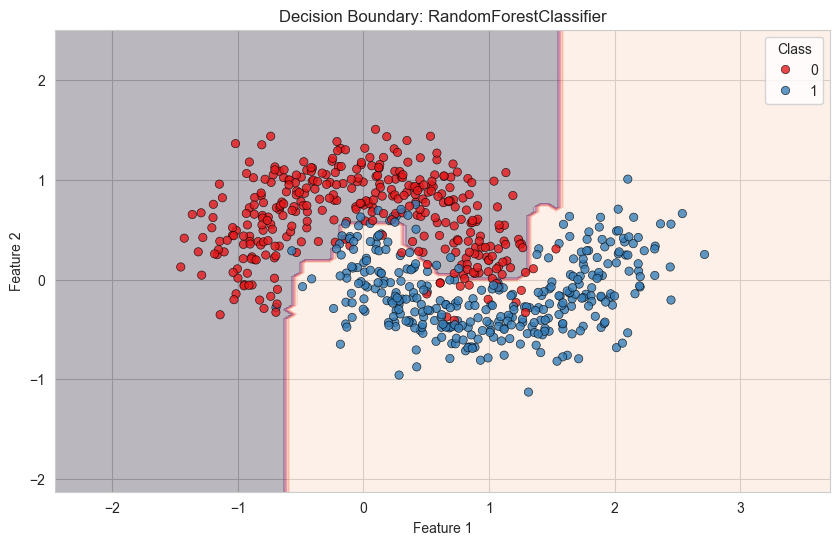

Decision Tree (max_depth=3)
  Train accuracy: 0.956
  Test accuracy:  0.967
  Train F1:       0.956
  Test F1:        0.966


In [27]:
# Explore key hyperparameters for Random Forest
n_estimators_list = [5, 20, 100]
max_depth_list = [3, 5, None]

for i, x in enumerate(n_estimators_list):

    simple_tree = RandomForestClassifier(
        max_depth=5, random_state=RANDOM_STATE,
        n_estimators=x
        
    )
    simple_tree.fit(X_train, y_train)

    plot_decision_boundary(simple_tree, X_train, y_train)

    # Evaluate
    y_train_pred = simple_tree.predict(X_train)
    y_test_pred = simple_tree.predict(X_test)

    print("Decision Tree (max_depth=3)")
    print(f"  Train accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
    print(f"  Test accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")
    print(f"  Train F1:       {f1_score(y_train, y_train_pred):.3f}")
    print(f"  Test F1:        {f1_score(y_test, y_test_pred):.3f}")

### Question 3.2: Random Forest Hyperparameters

Look at how the decision boundaries change when you vary `n_estimators` and `max_depth`.

- What is the effect of increasing `n_estimators` while keeping `max_depth` fixed?
- What is the effect of increasing `max_depth` while keeping `n_estimators` fixed?

**Answer (example):**
- I...


**Note:** In real-world projects, there are many **gradient boosting implementations** (e.g. XGBoost, LightGBM, CatBoost). Here we use `sklearn.ensemble.GradientBoostingClassifier` for simplicity and consistency with the rest of the sklearn API, but the high-level ideas (ensembles of shallow trees, learning rate, number of estimators) are very similar across libraries.


## 4. A Simple Neural Network (MLPClassifier)

Neural networks can also be used for small tabular classification problems via `sklearn.neural_network.MLPClassifier`.

They are less interpretable than trees, but can learn **smooth, non-linear decision boundaries**.

We will:
- Train a small neural network on the same dataset
- Compare its decision boundary and F1-score to the tree-based models
- Play with a few key hyperparameters:
  - `hidden_layer_sizes`
  - `alpha` (L2 regularization)
  - `max_iter`


# TODO Fit a MLP on the same data and visualize boundary

In [28]:
# Train a small neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(20,20),
    random_state=RANDOM_STATE,
    max_iter=1000,
    alpha=0.01,
)

### Question 4.1: Neural Network vs Trees

Compare the neural network to the tree-based models.

- How does the **shape** of the neural network decision boundary differ from the tree-based ones?
- How do the **F1-scores** compare?
- In this low-dimensional, small-data setting, would you prefer a tree ensemble or an MLP? Why?

**Answer (example):**
- The neural network tends to produce a **smooth, curved decision boundary** rather than axis-aligned steps.
- Its F1-score can be competitive with ensembles if tuned well, but it is **less interpretable** and more sensitive to hyperparameters (learning rate, architecture, regularization).
- For this small tabular problem, a **random forest or gradient boosting model** is often a good default: strong performance, reasonable training time, and some interpretability via feature importance.


## 5. Cross-Validation and Hyperparameter Search with GridSearchCV

So far we have **manually** tried a few hyperparameters and looked at the resulting decision boundaries.

In practice, we usually:
- Define a **parameter grid** of reasonable values
- Use **cross-validation** to estimate performance for each combination
- Select the **best model** according to a chosen metric

Here we will:
- Use `GridSearchCV` on a **RandomForestClassifier`
- Optimize for **F1-score** (on the positive class)
- Compare the best model from grid search to a baseline

We will keep the grid **small and didactic** so that it runs quickly.


# TODO - create a parameters' grid and cross-validate the RandomForestClassifier's hyperparams using `GridSearchCV`

Analyze difference between baseline and best estimator

In [33]:
# Baseline random forest
baseline_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
)

baseline_rf.fit(X_train, y_train)
y_test_pred_baseline = baseline_rf.predict(X_test)

baseline_f1 = f1_score(y_test, y_test_pred_baseline)
print(f"Baseline RandomForest F1 (test): {baseline_f1:.3f}")

# Define a small parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='f1', n_jobs=-1
)

Baseline RandomForest F1 (test): 0.960


In [34]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [35]:
# Inspect CV results as a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

cols_to_show = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
]

cv_results[cols_to_show].sort_values("mean_test_score", ascending=False).head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score
24,50,None,4,0.937195,0.017498
23,200,None,2,0.936058,0.018970
26,200,None,4,0.935882,0.019922
21,50,None,2,0.934799,0.017201
19,100,None,1,0.934660,0.028999
25,100,None,4,0.934091,0.020459
22,100,None,2,0.933236,0.019229
20,200,None,1,0.933162,0.027649
18,50,None,1,0.932812,0.031222
12,50,5,2,0.932210,0.025269


# TODO - plot 2d heatmaps of hyperparams to analyze the impact of each one on the model's overall performance

In [ ]:
# 2D visualization of F1 vs hyperparameters (heatmaps)

# Convert parameter columns to plain Python values
heatmap_df = cv_results.copy()
heatmap_df["n_estimators"] = heatmap_df["param_n_estimators"].astype(int)
heatmap_df["min_samples_leaf"] = heatmap_df["param_min_samples_leaf"].astype(int)
# max_depth can be int or None
heatmap_df["max_depth"] = heatmap_df["param_max_depth"].astype(str)

raise NotImplementedError("Fill out the TODO")

# Pivot tables: mean_test_score as a function of 2 hyperparameters
pivot_ne_md = ...

pivot_md_leaf = ...


### Question 5.2: Interpreting the F1 Heatmaps

Look at the two heatmaps of **mean CV F1** vs pairs of hyperparameters.

- Along which axis do you see the **largest changes** in F1? (e.g. `max_depth` vs `n_estimators`)
- Is there a region where performance **plateaus**, meaning extra complexity does not buy you much?
- How would you explain to a stakeholder why you chose a certain region of this grid (e.g. "simpler but nearly as good" vs "slightly better but more complex")?

**Answer (example):**
- ...

In [ ]:
# Visualize best model decision boundary vs baseline
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

plot_decision_boundary(baseline_rf, X_train, y_train, ax=axes[0], title=f"Baseline RF\nF1(test)={baseline_f1:.2f}")
plot_decision_boundary(best_rf, X_train, y_train, ax=axes[1], title=f"Best RF (GridSearchCV)\nF1(test)={best_f1:.2f}")

plt.tight_layout()
plt.show()

# Confusion matrices for baseline and best model
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_baseline, ax=axes[0])
axes[0].set_title("Baseline RF - Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_best, ax=axes[1])
axes[1].set_title("Best RF - Confusion Matrix")

plt.tight_layout()
plt.show()

### Question 5.1: Reading GridSearchCV Results

Look at the sorted cross-validation results and the comparison between the baseline and the best model.

- Did `GridSearchCV` find a configuration that **improves test F1** compared to the baseline? By how much?
- Which hyperparameters seem most influential in this small grid (e.g. `max_depth`, `min_samples_leaf`, `n_estimators`)?
- Why is it important to evaluate hyperparameters with **cross-validation** rather than a single train/test split?

**Answer (example):**
- ...


**Note:** `GridSearchCV` is a good starting point for small grids, but does not scale well to very large hyperparameter spaces. In practice, you might use more advanced tools such as **Optuna**, **sklearn's RandomizedSearchCV**, or specialized libraries in the gradient boosting ecosystem (XGBoost, LightGBM, CatBoost) to explore the space more efficiently.


## 6. Summary

In this session, we:

1. **Explored a non-linear dataset** and saw why linear decision boundaries can fail
2. **Trained and visualized decision trees**, connecting tree structure to 2D decision regions
3. **Compared ensembles** (Random Forest, Gradient Boosting) to a single tree and inspected the effect of key hyperparameters
4. **Introduced a simple neural network** via `MLPClassifier` and compared its decision boundary to tree-based models
5. **Used `GridSearchCV`** with a small, didactic grid to tune a random forest for **F1-score**

**Key takeaways:**
- Decision boundaries and visualizations are powerful tools to build **intuition** about model behavior.
- Ensembles of trees (Random Forest, Gradient Boosting) are strong baselines for many tabular problems.
- Neural networks can work on small tabular datasets, but often require more tuning and are less interpretable.
- Systematic hyperparameter search with **cross-validation** is essential to get reliable performance estimates.


# TODO - next, change parameters in the dataset creation (moons, classification_easy, classification_hard), play with them (esp. `noise`) and re-run above cells - ananlyze impact on CV, heatmaps, decision boundaries, ...